# Library assistant

*  LangGraph states are immmutable, they return partial updates. So the state does not need to update every field in the state message, it can just return some updates.

* Reducers are good when the state is accumulating.

* The library state should have the following fields: 
    * section(barrow, return, overdue, unknown)
    * messages list with add reducer so we can keep the messages history
    * books barrowed list, we can then update the list delete items or add items as books are returned and new books are barrowed.
    * last_user_message this is optional because it will be used in routing
    * resolved state bool
    

In [2]:
from typing import TypedDict, Literal, Optional, Annotated, List
from langgraph.graph.message import add_messages
import operator

class LibraryAssistantState(TypedDict):
    section: Optional[Literal["barrow", "return", "overdue", "unknown"]]
    messages: Annotated[str, add_messages]
    books_barrowed: List[str]
    last_user_message: Optional[str]
    resolved: bool = False


In [ ]:
def handle_return(state: LibraryAssistantState) -> LibraryAssistantState:
    return {}

def handle_barrow(state: LibraryAssistantState) -> LibraryAssistantState:
    return {}

def handle_overdue(state: LibraryAssistantState) -> LibraryAssistantState:
    return {}

def route_user(state: LibraryAssistantState) -> LibraryAssistantState:
    return {'resolved': True}

## Create the graph and compile it


In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# add all the nodes
workflow = StateGraph(LibraryAssistantState)
workflow.add_node("router", route_user)

def next_step(state: LibraryAssistantState):
    if state["resolved"]:
        return END
    return state["section"] or "router"

workflow.add_node("barrow", handle_barrow)
workflow.add_node("overdue", handle_overdue)
workflow.add_node("return", handle_return)


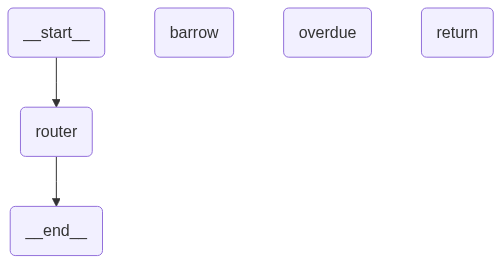

In [10]:
workflow.set_entry_point("router")
workflow.add_conditional_edges("router", next_step)
workflow.add_edge("barrow", END)
workflow.add_edge("return", END)
workflow.add_edge("overdue", END)

memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)

from IPython.display import Image, display
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)